Archivo 'car data.csv' cargado correctamente. Columnas: Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')
Archivo 'CAR DETAILS FROM CAR DEKHO.csv' cargado correctamente. Columnas: Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')
Archivo 'Car details v3.csv' cargado correctamente. Columnas: Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')
Archivo 'car details v4.csv' cargado correctamente. Columnas: Index(['Make', 'Model', 'Price', 'Year', 'Kilometer', 'Fuel Type',
       'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Engine',
       'Max Power', 'Max Torque', 'Drivetrain', 'Length', 'Width', 'Height',
       'Seating Capacity', 'Fuel Tank Capaci

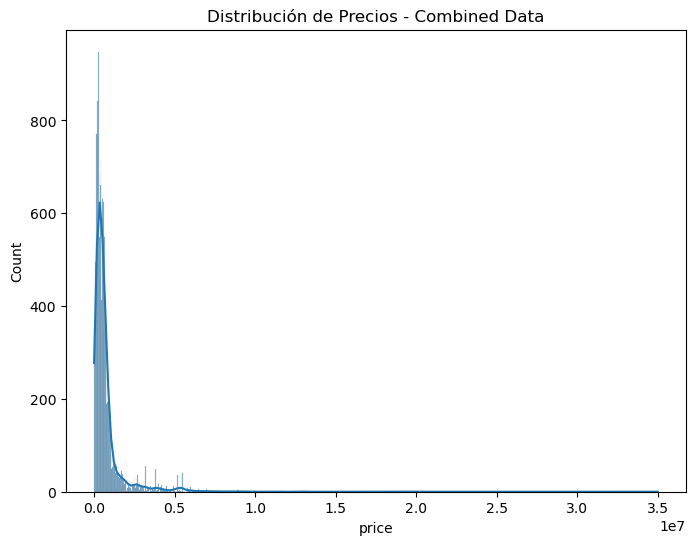

Error durante la visualización en EDA: could not convert string to float: 'ritz'

--- 3. Preprocesamiento de los datos ---

Filas al inicio del preprocesamiento: 14828

Valores faltantes por columna:
 Car_Name              14527
Year                  12468
price                     0
Present_Price         14527
Kms_Driven            14527
Fuel_Type             14527
Seller_Type           14527
Transmission          12468
Owner                 12468
name                   2360
year                   2360
km_driven              2360
fuel                   2360
seller_type            2360
transmission           2360
owner                  2360
mileage                6921
engine                 6921
max_power              6915
torque                 6922
seats                  6921
Make                  12769
Model                 12769
Kilometer             12769
Fuel Type             12769
Location              12769
Color                 12769
Seller Type           12769
Engine         

<Figure size 1200x1000 with 0 Axes>

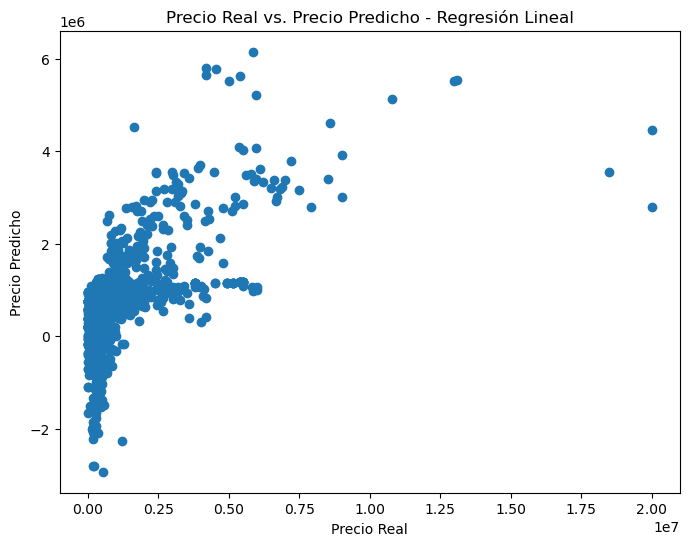

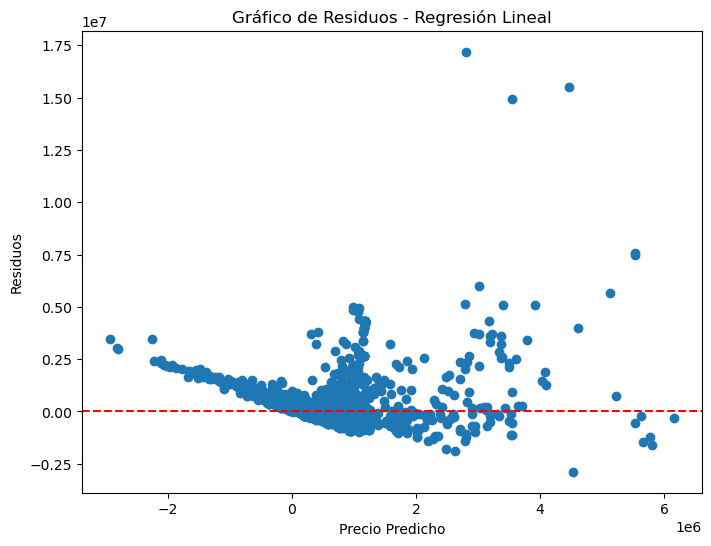


Validación Cruzada R^2: 0.3296493236374268 (std: 0.032679700551288236)


In [16]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.impute import SimpleImputer
import numpy as np

# 1. Cargar los datos
def load_and_combine_data(folder_path, target_column='price'):
    """Carga y combina los archivos CSV de una carpeta."""

    # Listar los archivos CSV en la carpeta
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

    # Verificar si hay archivos CSV
    if not csv_files:
        print("Error: No se encontraron archivos CSV en la carpeta.")
        return None  # Devuelve None si no hay archivos

    # Cargar los archivos CSV en DataFrames
    dfs = []
    for csv_file in csv_files:
        file_path = os.path.join(folder_path, csv_file)
        try:
            df = pd.read_csv(file_path)
            print(f"Archivo '{csv_file}' cargado correctamente. Columnas: {df.columns}")  # Imprimir columnas
            dfs.append(df)
        except Exception as e:
            print(f"Error al cargar {csv_file}: {e}")
            continue  # Continuar con el siguiente archivo si hay un error

    # Estandarizar el nombre de la columna objetivo y filtrar DataFrames
    valid_dfs = []
    for df in dfs:
        for col in df.columns:
            if target_column.lower() in col.lower():  # Comparación flexible de nombres
                df = df.rename(columns={col: target_column})
                valid_dfs.append(df)
                break
        else:
            print(f"Advertencia: El archivo no contiene una columna similar a '{target_column}'. Se omite.")

    # Combinar los DataFrames
    if valid_dfs:  # Solo combinar si hay DataFrames válidos
        combined_df = pd.concat(valid_dfs, ignore_index=True)
        print(f"\nArchivos combinados exitosamente. Columnas combinadas: {combined_df.columns}")  # Imprimir columnas combinadas
        return combined_df
    else:
        print("No se cargaron DataFrames válidos. No se puede continuar.")
        return None

# 2. Análisis Exploratorio de Datos (EDA)
def perform_eda(df, file_name="Combined Data"):
    """Realiza el Análisis Exploratorio de Datos."""

    print(f"\n--- 2. Análisis Exploratorio de Datos (EDA) - {file_name} ---\n")

    print("\nPrimeras 5 filas:\n", df.head())
    print("\nInformación del dataset:\n")
    df.info()
    print("\nDescripción estadística:\n", df.describe())

    # Visualizaciones
    try:
        if 'price' in df.columns:
            # Verificar si hay datos para graficar
            if not df.empty and 'price' in df.columns:
                plt.figure(figsize=(8, 6))
                sns.histplot(df['price'], kde=True)
                plt.title(f'Distribución de Precios - {file_name}')
                plt.show()  # Mostrar la gráfica

                plt.figure(figsize=(12, 10))
                sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
                plt.title(f'Matriz de Correlación - {file_name}')
                plt.show()  # Mostrar la gráfica
            else:
                print(f"Advertencia: No hay datos suficientes para generar las gráficas de EDA en {file_name}.")
        else:
            print("La columna 'price' no está presente en este dataset. No se generaron gráficas de EDA.")

    except KeyError as e:
        print(f"Error de clave en EDA: {e}. Asegúrate de que las columnas existen.")
    except (ValueError, TypeError) as e:
        print(f"Error durante la visualización en EDA: {e}")
    except Exception as e:
        print(f"Error inesperado durante la visualización en EDA: {e}")

# 3. Preprocesamiento de los datos
def preprocess_data(df):
    """Preprocesa los datos."""

    print("\n--- 3. Preprocesamiento de los datos ---\n")
    print("Filas al inicio del preprocesamiento:", len(df))

    print("\nValores faltantes por columna:\n", df.isnull().sum())
    df_before_dropna = df.copy() # Guardar una copia para comparar
    df = df.dropna(subset=['price']) # Eliminar filas solo si falta el precio
    print("Filas después de dropna (solo en 'price'):", len(df))
    print(f"Filas eliminadas por dropna (solo en 'price'): {len(df_before_dropna) - len(df)}")

    # Imputar valores numéricos y categóricos
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            imp = SimpleImputer(missing_values=np.nan, strategy='median')
            df[col] = imp.fit_transform(df[[col]])
        elif df[col].dtype == 'object':
            imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
            imputed_values = imp.fit_transform(df[col].values.reshape(-1, 1))
            df[col] = pd.Series(imputed_values.flatten(), index=df.index)

    print("\nValores faltantes después de la imputación:\n", df.isnull().sum())
    print("Filas después de la imputación:", len(df))

    # Manejar outliers (COMENTADO TEMPORALMENTE PARA DEPURACIÓN)
    print("\nFilas antes de manejar outliers:", len(df))
    df_before_outliers = df.copy()
    # for col in df.select_dtypes(include=np.number).columns:
    #     if col != 'price':
    #         df = df[(np.abs(df[col] - df[col].mean()) < (3 * df[col].std()))]
    print("Filas después de manejar outliers:", len(df))
    print(f"Filas eliminadas por outliers: {len(df_before_outliers) - len(df)}")

    categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
    numerical_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]

    print(f"Columna categoricas: {categorical_cols}")
    print(f"Columna numericas: {numerical_cols}")

    for col in categorical_cols:
        try:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
        except KeyError as e:
            print(f"Error de clave al codificar la columna {col}: {e}. La columna no existe.")
        except Exception as e:
            print(f"Error al codificar la columna {col}: {e}")

    print("\nDataFrame después del preprocesamiento:\n", df.head())
    print("Filas al final del preprocesamiento:", len(df))
    return df

# 4. Selección de características
def select_features(df, target_col='price', k=10, method='kbest'):
    """Selecciona las k mejores características para el modelo."""

    print("\n--- 4. Selección de características ---\n")

    numerical_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
    features = [col for col in numerical_cols if col != target_col]

    if target_col not in df.columns:
        print(f"Advertencia: La columna objetivo '{target_col}' no está presente. No se realizará selección de características.")
        return None, None, features  # Devuelve None para X, y, y la lista de características numéricas

    if not features:
        print("Error: No hay características numéricas disponibles para la selección.")
        return None, None, features

    X = df[features]
    y = df[target_col]

    if method == 'kbest':
        selector = SelectKBest(score_func=f_regression, k=min(k, len(features)))  # Usar f_regression para regresión
        selector.fit(X, y)
        selected_features = list(X.columns[selector.get_support(indices=True)])
    elif method == 'rfe':
        estimator = LinearRegression()
        selector = RFE(estimator, n_features_to_select=min(k, len(features)))
        selector.fit(X, y)
        selected_features = list(X.columns[selector.support_])
    else:
        raise ValueError("Método de selección de características no válido. Use 'kbest' o 'rfe'.")

    print("Características seleccionadas:", selected_features)

    return df[selected_features], df[target_col], selected_features

# 5. Entrenar el modelo
def train_model(X_train, y_train, model_type='linear', alpha=1.0):
    """Entrena el modelo de Regresión Lineal."""

    print("\n--- 5. Entrenar el modelo ---\n")

    if model_type == 'linear':
        model = LinearRegression()
    elif model_type == 'ridge':
        model = Ridge(alpha=alpha)
    elif model_type == 'lasso':
        model = Lasso(alpha=alpha)
    else:
        raise ValueError("Tipo de modelo no válido. Use 'linear', 'ridge' o 'lasso'.")

    model.fit(X_train, y_train)
    return model

# 6. Evaluar el desempeño
def evaluate_model(model, X_test, y_test, file_name=""):
    """Evalúa el desempeño del modelo."""

    print("\n--- 6. Evaluar el desempeño ---\n")

    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Resultados para: {file_name}")
    print(f"Mean Squared Error: {mse}")
    print(f"Mean Absolute Error: {mae}")
    print(f"R^2 Score: {r2}")
    return y_pred

# 7. Visualizar los resultados
def visualize_results(y_test, y_pred, file_name=""):
    """Visualiza los resultados del modelo."""

    print("\n--- 7. Visualizar los resultados ---\n")

    try:
        # Asegurar que los datos son arrays de NumPy
        y_test_np = np.array(y_test)
        y_pred_np = np.array(y_pred)

        # Verificar si hay datos para graficar
        if y_test_np.size > 0 and y_pred_np.size > 0:
            plt.figure(figsize=(8, 6))
            plt.scatter(y_test_np, y_pred_np)
            plt.xlabel("Precio Real")
            plt.ylabel("Precio Predicho")
            plt.title(f"Precio Real vs. Precio Predicho - {file_name}")
            plt.show()  # Mostrar la gráfica

            # Gráfico de residuos
            plt.figure(figsize=(8, 6))
            residuals = y_test_np - y_pred_np
            plt.scatter(y_pred_np, residuals)
            plt.xlabel("Precio Predicho")
            plt.ylabel("Residuos")
            plt.title(f"Gráfico de Residuos - {file_name}")
            plt.axhline(y=0, color='r', linestyle='--')  # Línea de referencia en y=0
            plt.show()
        else:
            print(f"Advertencia: No hay datos suficientes para generar la gráfica de resultados en {file_name}.")
    except (ValueError, TypeError) as e:
        print(f"Error durante la visualización de resultados: {e}")
    except Exception as e:
        print(f"Error inesperado durante la visualización de resultados: {e}")

# Main
folder_path = 'regresionlineal'
combined_df = load_and_combine_data(folder_path)

if combined_df is not None:
    perform_eda(combined_df)
    preprocessed_df = preprocess_data(combined_df.copy())

    X, y, selected_features = select_features(preprocessed_df.copy(), method='kbest')  # Puedes cambiar a 'rfe'

    if X is not None and y is not None:
        # Escalar características
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        model = train_model(X_train, y_train, model_type='linear')  # Puedes cambiar a 'ridge' o 'lasso'
        y_pred = evaluate_model(model, X_test, y_test, file_name="Regresión Lineal")
        visualize_results(y_test, y_pred, file_name="Regresión Lineal")

        # Validación cruzada
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
        print(f"\nValidación Cruzada R^2: {cv_scores.mean()} (std: {cv_scores.std()})")
    else:
        print("No se pudo realizar el modelado debido a la falta de datos.")
else:
    print("No se cargaron datos. El programa no puede continuar.")